# Solving Constrained Combinatorial Optimization Problems with QAOA

#### Learning Objectives

By the end of this lab, you should be able to:

- Represent a graph optimization problem as a Hamiltonian.
- Construct a QAOA circuit for constrained optimization problems.
- Understand the role of cost and mixer operators.
- Optimize QAOA parameters using a classical optimizer.
- Sample candidate solutions from a quantum circuit.
- Verify whether a sampled solution satisfies the problem constraints.
- Interpret the quality of solutions produced by QAOA.

---

#### Local python files


**`hamiltonian.py`**

Contains functionality for:

- Constructing problem Hamiltonians
- Building QAOA cost and mixer operators
- Generating QAOA circuits

**`qaoa.py`**

Contains functionality for:

- QAOA parameter optimization
- Expectation value evaluation
- Circuit execution utilities

**`utils.py`**

Contains functionality for:

- Graph visualization
- Solution validation
- Plotting and analysis utilities

Inspect/fill out the files to better understand the implementation details behind the workflow.

---

#### Workflow

In this notebook, we will:

1. Create a graph optimization problem.
2. Convert the problem into a quantum cost Hamiltonian.
3. Build a QAOA ansatz.
4. Optimize the QAOA parameters.
5. Sample candidate solutions from the optimized circuit.
6. Verify constraint satisfaction.
7. Visualize and interpret the resulting solution.

---

## SCOOP Formulations

In this notebook, we will formulate and run experiments for 
1. Minimum Vertex Cover using a penalty based QUBO, and,
2. through its SCOOP twin Maximum Profit Cover (doesn't require penalties!).

### Minimum Vertex Cover (MinVC)

The cost function for $\textit{MinVC}$ in the form of a QUBO is defined as per the specifications outlined in [1]. Given $\textit{VC}\subseteq V$, and $v\in V$, let $x_v$ be a binary variable whose value is $1$ if $v$ is included in the vertex cover $\textit{VC}$ ($v\in \textit{VC}$), and $0$ otherwise. 

As a QUBO, $\textit{MinVC}$  can be defined in the following way:

$$
\begin{align}
C_{\text{VC}}(\vec{x}) &= C_E^{VC}(\vec{x}) + C_V^{VC}(\vec{x}) \\
&= A \sum_{uv\in E} (1 - x_u)(1-x_v) + B \sum_{v} x_v
\end{align}
$$

The constraint that every edge $uv\in E$ has at least one of its vertices in the subset $\textit{VC}$ is encoded by 
$C_E^{VC}(\vec{x})$. Given edge $uv\in E$, if both $x_u$ and $x_v$ are assigned to be $0$, then $uv$ is uncovered and therefore $uv$ violates the constraint that $\textit{VC}$ is a vertex cover (and therefore adds a penalty of $A$ to the cost function). 

A trivial vertex cover arises when all $x_v \in V$ are set to $1$. The objective of minimizing the number of vertices in the subset leads to  $C_V^{VC}(\vec{x})$


### Maximum Profit Cover (MaxPC)
The binary variables for the $\textit{MaxPC}$ problem are similar to $\textit{MinVC}$. Each $x_v$ is a binary variable with value $1$ if $v$ is included in the profit cover $\textit{PC}$, and $0$ otherwise.

The total cost to be maximized for $\textit{PC}$ is
\begin{align}
 C_{\text{PC}}(\vec{x}) &= C_E^{PC}(\vec{x}) - C_V^{PC}(\vec{x}) \\
 &= \sum_{uv \in E} (x_u + x_v - x_ux_v) - \sum_{v} x_v
 \end{align}

$C_E^{PC}(\vec{x})$ denotes all of the edges that have been covered, and $C_V^{PC}(\vec{x})$ counts the vertices used for coverage. 

\noindent While the definitions for $C_{\text{VC}}(\vec{x})$ and $C_{\text{PC}}(\vec{x})$ may appear similar, $C_{\text{PC}}(\vec{x})$ has no penalty parameters that need to be set, since every binary variable assignment corresponds to a feasible solution.




In [2]:
# During development it is common to modify helper functions in external Python files. 
# The autoreload extension automatically reloads updated modules whenever a cell is executed, 
# allowing us to work interactively without restarting the notebook.
%load_ext autoreload
%autoreload 2

Import the libraries required for the lab.
"Local imports" implement the components of the problem, QAOA, and some helper routines.

In [3]:
import numpy as np
import networkx as nx

# Qiskit and Qiskit Runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService 
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler import generate_preset_pass_manager

# Local imports
from utils import plot_result
from hamiltonian import build_mpc_hamiltonian, build_mvc_hamiltonian, build_candidate_circuit
from qaoa import train_qaoa_circuit, sample_qaoa_circuit

/mnt/Firecuda/qaoa-comb-opt/qaoa.py:91: SyntaxWarning: invalid escape sequence '\T'
  print(f"\Training result: {result}\n")


#### IBM Credentials
QAOA circuits can be executed on either a simulator or real quantum hardware.

In this lab we will primarily use simulation, but the same workflow can be executed on IBM Quantum backends with minimal changes.
Update your account by filling in the token/API Key and instance. These are available on the IBM dashboard. 

See more here: https://quantum.cloud.ibm.com/docs/en/guides/save-credentials

##### IBM Quebec
Heron r2/r3 processors such as IBM Quebec provide us with fractional gates. With fractional gates, $RZZ$ and $RX$ gates are natively implemented (thereby reducing depth of the circuit). 
Learn more about fractional gates here: https://quantum.cloud.ibm.com/docs/en/guides/fractional-gates



In [6]:

# QiskitRuntimeService.save_account(
#   token="<YOUR API KEY>", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard

#   instance="<YOUR CRN>", # Optional
#   set_as_default=True, # Optional
#   overwrite=True, # Optional
# )

service = QiskitRuntimeService(channel="local")
backend = service.backend('fake_quebec')#, use_fractional_gates=True) # change the backend if it is not IBM Quebec


Generate a random graph to solve the Minimum Vertex Cover problem. Take a moment to inspect the graph before continuing.

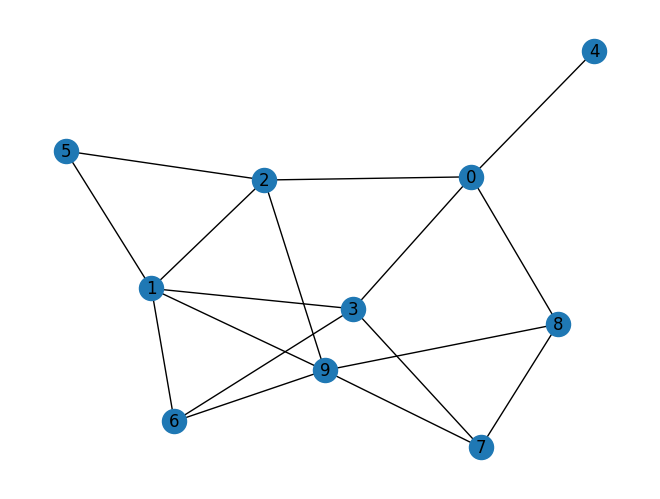

In [7]:
# generate a random graph
graph = nx.erdos_renyi_graph(n=10, p=0.3, seed=42)
pos = nx.kamada_kawai_layout(graph)
nx.draw(graph, pos=pos, with_labels=True)

QAOA does not operate directly on graphs. Instead, we convert the optimization problem into a cost Hamiltonian whose low-energy states correspond to desirable solutions.

The helper functions below generate the Pauli terms that define the Hamiltonian. Recall the QUBOs for $\textit{MinVC}$ and $\textit{MaxPC}$. To convert QUBO (which is composed of binary variables $x_i  \in \{0, 1\}$) to Ising (composed of spin variables $z_i \in \{-1, 1\}$), we need to map $$x_i = \frac{1 - Z_i}{2}$$

## Your Task 
Derive the cost Hamiltonians for Minimum Vertex Cover and Maximum Profit Cover. Refer to [2] for the final Hamiltonians. 

### Minimum Vertex Cover (MinVC)
$$
\begin{align*}
C_{\text{VC}}(\vec{x}) &= C_E^{VC}(\vec{x}) + C_V^{VC}(\vec{x}) \\
&= A \sum_{uv\in E} (1 - x_u)(1-x_v) + B \sum_{v} x_v \\
C_{\text{VC}}(\vec{z}) &= ?
\end{align*}
$$

### Maximum Profit Cover (MaxPC)
$$
\begin{align*}
 C_{\text{PC}}(\vec{x}) &= C_E^{PC}(\vec{x}) - C_V^{PC}(\vec{x}) \\
 &= \sum_{uv \in E} (x_u + x_v - x_ux_v) - \sum_{v} x_v \\
 C_{\text{PC}}(\vec{z}) &= ?
 \end{align*}
$$

Using functions in `qaoa.py`, we construct the cost Hamiltonians and generate the circuits representing each of the optimization problems on the input graph. These Hamiltonians encode the objective function and constraints (if they exist) of each problem. We then generate the corresponding QAOA candidate circuits with `reps` indicating the number of layers. The `QAOAAnsatz` package generates the QAOA QuantumCircuit by combining the problem-specific cost Hamiltonian with a mixer Hamiltonian to create a parameterized quantum circuit whose parameters will later be optimized by a classical optimizer. Based on the chosen, the circuit is then transpiled into its basis gates.

In [8]:
mvc_hamiltonian = build_mvc_hamiltonian(graph)
mpc_hamiltonian = build_mpc_hamiltonian(graph)

In [9]:
candidate_circuit_mvc = build_candidate_circuit(graph, mvc_hamiltonian, backend, reps=1)
candidate_circuit_mpc = build_candidate_circuit(graph, mpc_hamiltonian, backend, reps=1)

#### Training the QAOA circuit to obtain optimal parameters

The parameterized QAOA circuit is trained using a classical optimization loop. The function `train_qaoa_circuit()` takes the candidate QAOA circuit, the problem Hamiltonian, and an initial set of variational parameters as input. During training, the circuit is repeatedly executed on the specified backend (e.g., a simulator), and the expectation value of the  Hamiltonian is evaluated.
The classical optimizer adjusts the QAOA parameters to minimize the Hamiltonian expectation value, corresponding to finding lower-cost solutions to the optimization problem. This hybrid quantum-classical process continues until a stopping criterion is met, such as convergence or a maximum number of optimization iterations.
The resulting object, `training_results`, contains the optimized QAOA parameters along with information about the optimization process, such as the objective values obtained during training. These optimized parameters are subsequently used to generate candidate solutions by sampling from the trained QAOA circuit.

In [10]:
# From https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm
#  QAOA doesn't prescribe principled default angles — any bounded choice
# works as a warm start for problems this small. beta and gamma are
# periodic (beta in [0, pi] and gamma in [0, 2*pi] modulo the underlying
# Pauli-rotation periods), and pi/2 and pi are just midpoints of those
# ranges. For harder problems you would typically warm start from known
# good angles or transfer parameters from smaller instances.
initial_gamma = np.pi
initial_beta = np.pi / 2
init_params = [initial_beta, initial_gamma]

In [11]:
training_results = train_qaoa_circuit(backend, candidate_circuit_mpc, mpc_hamiltonian, init_params, simulator=True)

Optimization started at: 2026-06-23 13:09:27

Objective function evaluation 0: 0.0297 seconds
Objective function evaluation 1: 0.0199 seconds
Objective function evaluation 2: 0.0159 seconds
Objective function evaluation 3: 0.0135 seconds
Objective function evaluation 4: 0.0132 seconds
Objective function evaluation 5: 0.0133 seconds
Objective function evaluation 6: 0.0137 seconds
Objective function evaluation 7: 0.0148 seconds
Objective function evaluation 8: 0.0148 seconds
Objective function evaluation 9: 0.0138 seconds
Objective function evaluation 10: 0.0189 seconds
Objective function evaluation 11: 0.0190 seconds
Objective function evaluation 12: 0.0161 seconds
Objective function evaluation 13: 0.0152 seconds
Objective function evaluation 14: 0.0190 seconds
Objective function evaluation 15: 0.0129 seconds
Objective function evaluation 16: 0.0157 seconds
Objective function evaluation 17: 0.0137 seconds
Objective function evaluation 18: 0.0212 seconds
Objective function evaluation 19:

#### Sampling solutions from the circuit
After the QAOA parameters have been optimized, the trained circuit is assigned the new parameters and is measured (sampled) to generate candidate solutions to the optimization problem.

In [12]:
optimized_circuit = candidate_circuit_mpc.assign_parameters(training_results['result'].x)
optimized_circuit.measure_active()

In [13]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
xp_optimized_circuit = pm.run(optimized_circuit)
sampling_results = sample_qaoa_circuit(backend, xp_optimized_circuit, graph, simulator=True, num_shots=100000)

Sampling started at: 2026-06-23 13:09:32

Sampling job time: 0.0005 seconds
{'0010101111': 0.00111, '0011101011': 0.00151, '1011010111': 0.00564, '0011100111': 0.00378, '1101001101': 0.00514, '0101100111': 0.00098, '0111000111': 0.01323, '1101000110': 0.0007, '1101011011': 0.00132, '0100110100': 7e-05, '1111000111': 0.00692, '1000001111': 0.00746, '0011010111': 0.00312, '1110001110': 0.00451, '1111010111': 0.00258, '1100011110': 0.01235, '0001100011': 0.00017, '0100001101': 0.00028, '0111001110': 0.00536, '1111110100': 0.00117, '0110111111': 0.00085, '1010101011': 0.00952, '1100011111': 0.00344, '1101001110': 0.00461, '0011011110': 0.00155, '1111101001': 0.00202, '1111011101': 0.00076, '0111101100': 0.00233, '1011000011': 0.0068, '1000011111': 0.00258, '0011011111': 0.002, '0111111100': 0.00352, '1111010101': 0.0005, '1100101011': 0.011, '1101011111': 0.0025, '1010011110': 0.00552, '1111000110': 0.00155, '0111111110': 0.00405, '0111100111': 0.0066, '1001000111': 0.00175, '0101000111': 

#### Classical post-processing to generate a feasible result

To convert the results for the unconstrained profit problem (i.e., solutions for \textit{MaxPC}) to results of the constrained problem (i.e. \textit{MinVC}), we apply polynomial-time classical post-processing that runs in $\mathcal{O}(|E|)$ time. See the equivalence theorems and algorithm definitions in [2]. The `ensure_vertex_cover(graph, bitstring)` applies the following post-processing:
1. Iterate over each uncovered edge (i.e., an edge with neither end points in the cover)
2. Add one of the end-points to the cover

Why does this not change the profit? 

In [14]:
from utils import ensure_vertex_cover

# Post-process the most likely bitstring to ensure it's a valid vertex cover
pc_bitstring = sampling_results['most_likely_bitstring']
vc_bitstring = ensure_vertex_cover(graph, pc_bitstring)

print(f"Profit Cover bitstring: {pc_bitstring}")
print(f"Processed bitstring (valid vertex cover): {vc_bitstring}")


Profit Cover bitstring: [1, 1, 1, 0, 0, 0, 1, 1, 1, 0]
Processed bitstring (valid vertex cover): [1, 1, 1, 0, 0, 0, 1, 1, 1, 0]


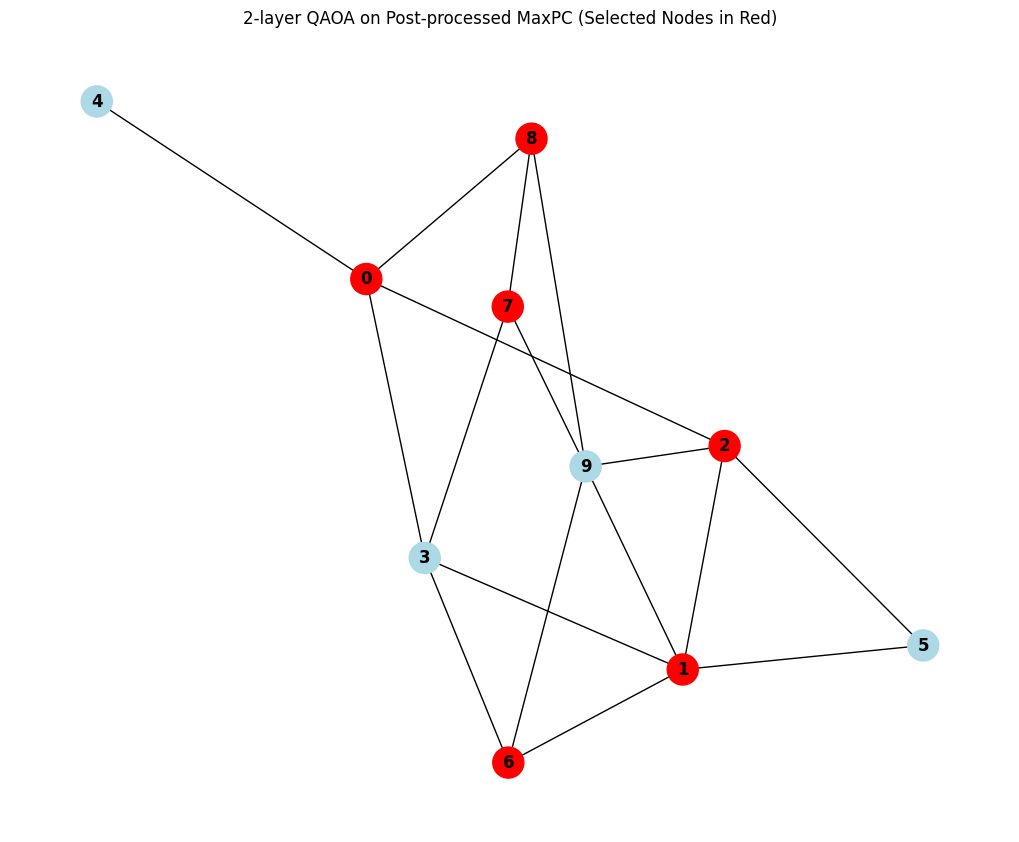

In [15]:
plot_result(graph, vc_bitstring, 'test', title="2-layer QAOA on Post-processed MaxPC (Selected Nodes in Red)")

### Lab Challenges
1. Run a different example - how do denser graphs compare to sparse graphs? 
2. Compare results of MinVC and MaxPC
3. Change the number of layers/penalties/optimizers - how does this affect the results?
4. Derive and implement the HUBO's for Dominating Set and Profit Domination. 


### References

[1] Lucas A (2014) Ising formulations of many NP problems. Front. Physics 2:5. doi: 10.3389/fphy.2014.00005

[2] Prashanti Angara, Danylo Lykov, Ulrike Stege, Yuri Alexeev, Hausi Müller, “The Art of Avoiding Constraints: A Penalty-free Approach to Constrained Combinatorial Optimization with QAOA”, 2025,  available on arXiv:2503.10077

[3] Prashanti Angara, Emily Martins, Ulrike Stege, Hausi Müller, “SCOOP: A Quantum-Computing Framework for Constrained Combinatorial Optimization”, QCE 2025, available on arXiv:2504.10897

[4] Prashanti Angara, Felipe Rivera, Ibrahim Shehzad, Ulrike Stege, Hausi Müller, “Experimental workflows for combinatorial optimization: Towards quantum advantage”, 2026, available on arXiv:2604.25162
